# Projeto de Ciência de Dados — Detecção de Fraudes em Cartão de Crédito

**Tema:** *Credit Card Fraud Detection*
**Nível:** Graduação  
**Curso:** Ciência da computação

## Integrantes do grupo

| Nome | Matrícula ||
|---|---:|---|
| Erico Gonçalves Guedes | 2023201635 |
| Iago de Sousa Cerqueira | 2022200744 |




## Introdução

Fraudes em cartão de crédito são um problema recorrente em sistemas financeiros e plataformas digitais.  
Do ponto de vista de ciência de dados, trata-se de um cenário que borda a  **detecção de anomalias**, pois as fraudes representam uma **minoria extremamente rara** em comparação com transações legítimas, em relação ao dataset apresentado.

Neste projeto, construímos e avaliamos modelos para classificar transações potencialmente fraudulentas, discutindo limitações, trade-offs (ex.: *precision* vs. *recall*) e escolhas metodológicas adequadas para lidar com esse dataset que possue **dados extremamentes desbalanceados**.


## Definição do problema

**Objetivo:** dado um conjunto de transações, classificar cada transação como:

- **0**: legítima  
- **1**: fraude  

**Tipo de problema:** classificação binária, com forte desbalanceamento de classes.  
**Critérios de avaliação (principais):**
- *Precision*, *Recall* e *F1* para a classe fraude (1)
- **PR-AUC** (*Average Precision*) como métrica mais informativa em bases desbalanceadas  
- ROC-AUC como métrica complementar

> Em aplicações reais, o custo de **falsos negativos** (fraudes não detectadas) costuma ser alto, mas muitos **falsos positivos** (bloqueios indevidos) também impactam a experiência do usuário. Por isso, o **threshold** de decisão pode ser ajustado.


## Descrição do conjunto de dados

### Contexto
É importante que operadoras e instituições financeiras reconheçam **transações fraudulentas** para evitar que clientes sejam cobrados por compras que não realizaram.

### Conteúdo e origem
**Fonte:** dataset público do Kaggle (*mlg-ulb/creditcardfraud*), com transações realizadas por **portadores de cartão europeus** em **setembro de 2013**.  
O conjunto contém transações registradas em **dois dias**, totalizando **284.807** transações, das quais **492** são fraudes (**0,172%**).  
Assim, trata-se de um caso **altamente desbalanceado**, onde a classe positiva (*fraude*) é extremamente rara.

### Variáveis
O dataset possui apenas variáveis numéricas. Devido a questões de confidencialidade, as variáveis originais não são disponibilizadas:  
- `V1` a `V28`: componentes principais obtidas por uma transformação **PCA** (atributos transformados para preservar privacidade).  
- `Time`: segundos decorridos desde a primeira transação do conjunto.  
- `Amount`: valor monetário da transação (útil para análises sensíveis a custo e normalmente requer padronização/normalização).  
- `Class`: variável-alvo (**1 = fraude**, **0 = legítima**).

### Observação sobre avaliação
Como a base é **muito desbalanceada**, **acurácia** e “accuracy” da matriz de confusão podem ser pouco informativas.  
Uma métrica recomendada para este cenário é a **Área sob a Curva Precisão-Revocação (AUPRC / PR-AUC)**, além de **Precision**, **Recall** e **F1**.



## Metodologia

  



## 1. Descrição dos Metodos Utilizados




### Pipeline aplicado no notebook  
No notebook, os métodos foram utilizados seguindo este encadeamento de etapas:

1. **Separar features e variável alvo (target)**  
   Primeiro separamos `X` (variáveis explicativas) e `y` (classe: fraude vs. não fraude), organizando o dataset para os próximos passos.

2. **Dividir os dados em treino e teste (train/test split)**  
   A divisão em conjuntos de treinamento e teste permite avaliar o modelo de forma realista, verificando o quanto ele generaliza para dados não vistos. Esse passo evita uma avaliação irreal.

3. **Padronizar as variáveis (standardization)**  
   A padronização é essencial para o pipeline porque métodos como **LDA** e **SVM** são sensíveis à escala das features. Ao transformar as variáveis para média 0 e desvio padrão 1, garantimos que nenhuma feature domine o aprendizado apenas por ter valores maiores.

4. **Aplicar técnicas para lidar com desbalanceamento** 
   Como a classe de fraude é extremamente rara, utilizamos técnicas para reduzir o efeito do desbalanceamento no treinamento. Em particular, aplicamos métodos como **SMOTE** (oversampling) apenas no conjunto de treino, gerando exemplos sintéticos da classe minoritária para que o modelo aprenda melhor os padrões de fraude.

5. **Aplicar os modelos escolhidos** 
   Com os dados preparados, treinamos os classificadores selecionados (por exemplo, **SVM** e **Random Forest**). 

6. **Avaliar o desenpenho dos modelos**
   Avaliamos os modelos com métricas adequadas, como `Precision`, `Recall` e `F1-score`, além de métricas baseadas em score contínuo como `ROC-AUC` e `AP-AUC` (PR-AUC). Também utilizamos matriz de confusão e **classification report** para interpretar os acertos e erros do modelo.

### Tratamento do Desbalanceamento com SMOTE  
O dataset de fraude é altamente desbalanceado, com muito mais transações não fraudulentas do que fraudulentas. Para reduzir esse problema, utilizamos o **SMOTE (Synthetic Minority Over-sampling Technique)**.

O SMOTE gera amostras sintéticas da classe minoritária com base em vizinhos próximos, criando exemplos interpolados em vez de apenas duplicar registros. Isso torna o conjunto de treino mais balanceado e ajuda o modelo a aprender padrões de fraude de forma mais efetiva.

> O SMOTE é aplicado somente no conjunto de treino, evitando vazamento de informação  e preservando a validade da avaliação no teste.

### Seleção de Features com SelectKBest (SelectKFeatures)  
Utilizamos seleção de atributos por meio do **SelectKBest**, que escolhe diretamente as *K* variáveis mais relevantes para a tarefa de classificação.

Cria novas variáveis como combinações lineares das originais, o SelectKBest:
- **mantém as features originais**, e
- **remove as menos informativas**, reduzindo ruído e complexidade.

No nosso caso, aplicamos o SelectKBest com um critério supervisionado (ex.: `f_classif`), que avalia o quanto cada feature ajuda a separar as classes (fraude vs. não fraude). De forma simplificada, esse critério mede se os valores de uma feature diferem significativamente entre as duas classes.

Em resumo, o SelectKBest busca atributos que:
- tenham maior poder discriminativo entre as classes, e
- reduzam dimensionalidade sem perder interpretabilidade, pois as features selecionadas continuam sendo parte do conjunto original.

Essa etapa pode melhorar o desempenho do classificador (por exemplo, SVM), pois reduz variáveis redundantes e facilita o aprendizado, principalmente em cenários com muitas features e classes desbalanceadas.


### Redução de Dimensionalidade com LDA (Linear Discriminant Analysis)  
Após padronização e balanceamento, aplicamos **LDA** como técnica de redução de dimensionalidade. Diferente de PCA, o LDA é supervisionado, ou seja, utiliza as classes para encontrar uma projeção que maximiza a separação entre fraude e não fraude.

O LDA procura uma combinação linear das variáveis que:
- **aumente a distância entre as classes** (médias das classes ficam mais separadas), e ao mesmo tempo
- **reduza a variância dentro de cada classe** (pontos de uma mesma classe ficam mais “compactos”).  

Em outras palavras, ele busca eixos onde fraude e não fraude fiquem o mais separadas possível, usando a informação do rótulo para “guiar” a redução de dimensionalidade.

### Modelagem com Random Forest (Floresta Aleatória)  
Utilizamos o **Random Forest** como algoritmo de classificação. Esse modelo é um método de *ensemble* que combina diversas **árvores de decisão** treinadas com variações dos dados e (geralmente) subconjuntos de atributos, produzindo uma predição final mais robusta e menos sensível a ruídos do que uma única árvore.

No notebook, seguimos estas etapas com Random Forest:

1. **Treinar o modelo**  
   O classificador foi instanciado com `n_estimators=100`, ou seja, uma floresta com 100 árvores. Além disso, foi utilizado `n_jobs=-1` para paralelizar o treinamento e `random_state` para garantir reprodutibilidade.  
   Em seguida, o modelo foi treinado sobre o conjunto balanceado (`X_train_over`, `y_train_over`), que já passou pelo tratamento de desbalanceamento.

2. **Gerar previsões no conjunto de teste**  
   Após o treinamento, o modelo foi aplicado ao conjunto de teste (`X_test_scaled`) para produzir:
   - `y_pred_RF`: a classe prevista(fraude ou não fraude), e
   - `y_score_RF`: a probabilidade da classe fraude, obtida com `predict_proba(... )[:, 1]`, que fornece um score contínuo para avaliação por diferentes limiares.

3. **Armazenar os resultados para avaliação posterior**  
   As previsões e os scores foram adicionados à lista `predicted_results`, permitindo comparar métricas entre modelos de forma padronizada (por exemplo, matriz de confusão, *classification report*, ROC-AUC e AP-AUC).


### Modelagem com SVM (Support Vector Machine)  
Por fim, utilizamos **SVM** como o algoritmo de classificação. O SVM busca uma fronteira de decisão que separa as classes com maior margem possível, funcionando bem em problemas lineares e não lineares.

No notebook, seguimos estas etapas com SVM:

1. **Treinar o modelo (com possibilidade de ajuste de hiperparâmetros)**  
   O desempenho do SVM pode variar com hiperparâmetros como:
   - `kernel` (tipo de separação),
   - `C` (regularização),
   - `gamma` (influência dos pontos em kernels como RBF).  
   Idealmente, esses valores podem ser ajustados com **grid search** ou **randomized search**, mas para simplificação o notebook demonstra também treino com hiperparâmetros padrão.

2. **Fazer previsões no conjunto de teste**  
   Após treinado, o modelo realiza a classificação das transações no teste para comparar com os rótulos reais.

3. **Armazenar os resultados para avaliação posterior**  
   As previsões e os scores foram adicionados à lista `predicted_results`, permitindo comparar métricas entre modelos de forma padronizada (por exemplo, matriz de confusão, *classification report*, ROC-AUC e AP-AUC).

## 2. Implantação do Problema

### Exploração e Pré-processamento de Dados

Esta seção do notebook é dedicada à exploração inicial e ao pré-processamento do conjunto de dados de fraude em cartão de crédito. O objetivo é preparar os dados para análises posteriores e para a modelagem usando algoritmos de Support Vector Machine (SVM).

Importação de Bibliotecas

Começamos importando as bibliotecas Python necessárias para operações numéricas, manipulação de dados, visualização e tarefas de aprendizado de máquina. Isso inclui bibliotecas como NumPy, pandas, Matplotlib, seaborn e scikit-learn, entre outras. Além disso, suprimimos avisos (warnings) para manter a saída mais limpa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve, auc, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import KFold
import kagglehub
import os


import warnings
warnings.filterwarnings('ignore')

USE_TIME_FEATURE = True
# USE_TIME_FEATURE = False


RANDOM_STATE = 42

C:\Users\User\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Carregamento dos Dados

O dataset é obtido a partir do Kaggle:

- Link: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Ao entrar no site via o link procure o botão de download no canto superior direito e baixe o zip do dataset.

No notebook, o dataset é carregado a partir de um arquivo CSV (`creditcard.csv`) localizado no diretório baixado. Exibimos o número de linhas e colunas para entender o tamanho do conjunto de dados e usamos o método `info()` para obter um resumo dos tipos de dados e das contagens de valores não nulos.


In [2]:
FILE_PATH = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
FILE_NAME = "creditcard.csv"


data = pd.read_csv(os.path.join(FILE_PATH, FILE_NAME))
print(f"Dataset Shape: {data.shape}")
print(f"Fraud Distribution: \n{data['Class'].value_counts(normalize=True) * 100}\n")
data.head()

Dataset Shape: (284807, 31)
Fraud Distribution: 
0    99.827251
1     0.172749
Name: Class, dtype: float64



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Number of columns: {}".format(data.shape[1]))
print("Number of rows: {}".format(data.shape[0]))

Number of columns: 31
Number of rows: 284807


In [4]:
print("\nDataset Information:")
data.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  f

Verificações de Qualidade dos Dados

Realizamos verificações de valores ausentes e de duplicatas. Constatamos que o dataset não possui valores ausentes, e quaisquer duplicatas são removidas para garantir a qualidade dos dados. Também padronizamos a coluna 'Amount' e removemos a coluna 'Time' como parte do pré-processamento.

In [5]:
print("\nMissing Values Check:")
print(data.isnull().sum())


Missing Values Check:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


###Análise Exploratória de Dados (EDA)
Distribuição de Classes

Analisamos a distribuição das classes para entender o equilíbrio entre casos de fraude e não fraude. O conjunto de dados é altamente desbalanceado, com um número significativamente maior de transações não fraudulentas em comparação com as fraudulentas.

In [6]:
data['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

Resumo Estatístico

É fornecido um resumo estatístico do dataset, oferecendo insights sobre tendência central e dispersão das variáveis numéricas.

In [7]:
print("\nStatistical Summary:")
print(data.describe())


Statistical Summary:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00 

### Pré-processamento de Dados
Padronização e Detecção de Outliers

A coluna 'Amount' é padronizada para ter média 0 e desvio padrão 1. Verificamos a existência de outliers na coluna 'Amount', mas não encontramos nenhum.

In [8]:
scaler = StandardScaler()
data['Amount'] = scaler.fit_transform(pd.DataFrame(data['Amount']))

In [9]:
if USE_TIME_FEATURE is False:
    # Possibly irrelevant
    print("Drop feature 'Time'")
    data = data.drop(['Time'], axis=1)

Resumo da Limpeza dos Dados

Concluímos que, após a limpeza, o dataset não possui valores nulos, outliers ou duplicatas, ficando pronto para análises posteriores.

In [10]:
print("\nChecking for Duplicates:")
if data.duplicated().any():
    print("Duplicates Found!")
    data = data.drop_duplicates()
else:
    print("No Duplicates Found.")


Checking for Duplicates:
Duplicates Found!


In [11]:
outliers = (data['Amount'] > 1000).sum()
print("\nOutliers in 'Amount' Column:", outliers)


Outliers in 'Amount' Column: 0


### Redução de Dimensionalidade com LDA

Aplicamos Linear Discriminant Analysis (LDA) para reduzir a dimensionalidade do dataset, preservando o máximo possível de informação discriminante entre as classes.

Etapas do LDA

O processo envolve: separar as features e a variável alvo, dividir os dados em treino e teste, padronizar as features, lidar com o desbalanceamento de classes usando SMOTE e, por fim, aplicar o LDA.

**separar as features e a variável alvo**

In [12]:
X = data.drop('Class', axis=1)
y = data['Class']

**dividir os dados em treino e teste**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)



**padronizar as features**

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lidar com o desbalanceamento de classes usando SMOTE

In [15]:
print("\nAddressing Class Imbalance with SMOTE:")
smote = SMOTE(random_state=0)
X_train_over, y_train_over = smote.fit_resample(X_train_scaled, y_train)


print("Before SMOTE: ", X_train.shape, y_train.shape)
print("After SMOTE: ", X_train_over.shape, y_train_over.shape)
print("After SMOTE Label Distribution: ", pd.Series(y_train_over).value_counts())


Addressing Class Imbalance with SMOTE:
Before SMOTE:  (198608, 30) (198608,)
After SMOTE:  (396538, 30) (396538,)
After SMOTE Label Distribution:  0    198269
1    198269
Name: Class, dtype: int64


Visualização da Distribuição de Classes

Visualizamos a distribuição de classes antes e depois da aplicação do SMOTE para evidenciar a eficácia da técnica em balancear o dataset.

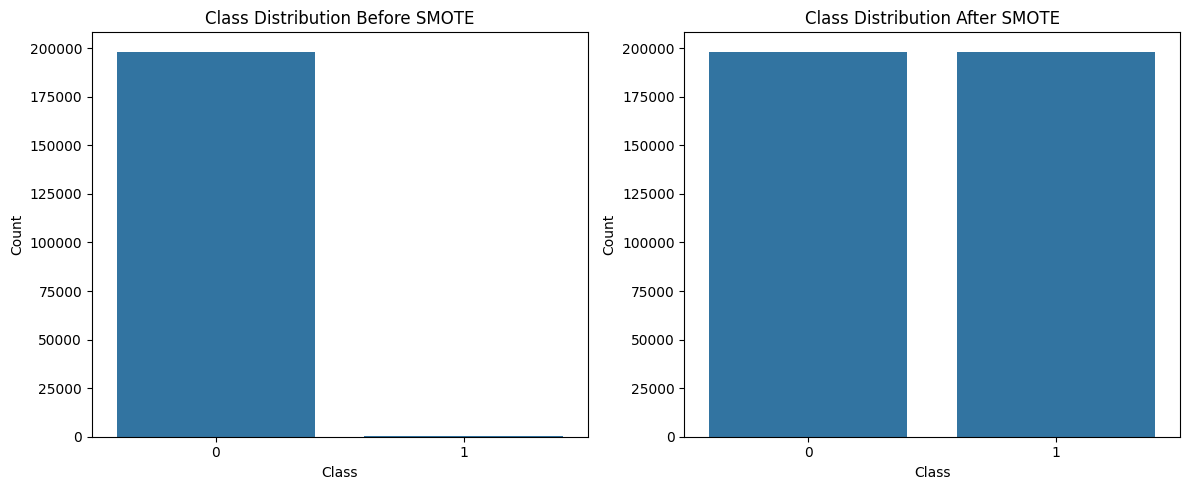

y_train size: 198608
y_train_over size: 396538
Before:
 0    198269
1       339
Name: Class, dtype: int64
After:
 0    198269
1    198269
Name: Class, dtype: int64


In [16]:
before = y_train.value_counts().sort_index()
after  = y_train_over.value_counts().sort_index()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=before.index, y=before.values)
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.barplot(x=after.index, y=after.values)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

print("y_train size:", len(y_train))
print("y_train_over size:", len(y_train_over))
print("Before:\n", y_train.value_counts())
print("After:\n", y_train_over.value_counts())


Aplicação do LDA para redução da Dimensionalidade

Por fim aplica o LDA nos dados tratados.

In [17]:
lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train_over, y_train_over)
X_test_lda = lda.transform(X_test_scaled)

Aplicação do Select K Features para selecionar as melhores features do dataset



In [18]:
selector = SelectKBest(score_func=f_classif, k=15)

X_train_sel = selector.fit_transform(X_train_over, y_train_over)
X_test_sel  = selector.transform(X_test_scaled)

selected_features = X_train.columns[selector.get_support()]
print("Selected Features:")
print(selected_features)

Selected Features:
Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V9', 'V10', 'V11', 'V12',
       'V14', 'V16', 'V17', 'V18'],
      dtype='object')


### Localização dos Resultados por Metodo

In [19]:


predicted_results = []

def get_confusion_matrix(y_test, y_pred):
  print("Confusion Matrix:")
  cm = confusion_matrix(y_test, y_pred)
  print(cm)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(values_format="d")  # mostra os valores inteiros

  plt.title("Confusion Matrix")
  plt.show()

  # Return the components of the confusion matrix for scoring functions
  return cm.ravel()

def get_scores(y_test, y_pred, y_score=None, name="NoNameModel"):
  TN, FP, FN, TP = get_confusion_matrix(y_test, y_pred)

  precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
  recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
  f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

  # Métricas que precisam de score contínuo (probabilidade ou decision_function)
  roc_auc = roc_auc_score(y_test, y_score) if y_score is not None else None
  ap_auc  = average_precision_score(y_test, y_score) if y_score is not None else None

  scores = {
      "precision": precision,
      "recall": recall,
      "f1": f1,
      "roc_auc": roc_auc,
      "ap_auc": ap_auc
  }

  print(f"\n\n {name}")
  print("\nMétricas calculadas (classe positiva = fraude):")
  print(f"Precision: {precision:.4f}")
  print(f"Recall:    {recall:.4f}")
  print(f"F1-score:  {f1:.4f}")
  
  if y_score is not None:
      print(f"ROC-AUC:   {roc_auc:.4f}")
      print(f"AP-AUC:    {ap_auc:.4f}")
  else:
      print("ROC-AUC:   (não calculado — forneça y_score)")
      print("AP-AUC:    (não calculado — forneça y_score)")

  return scores["f1"], scores  # Returning F1-score for comparison

def get_classification_report(y_test, y_pred, name="NoNameModel"):
  print(f"\n\n{name}")
  print("\nClassification Report:")
  print(classification_report(y_test, y_pred))

### Random Forest como classificador base

O Random Forest (Floresta Aleatória) é apresentado como um algoritmo de classificação baseado em *ensemble*, que combina múltiplas árvores de decisão para produzir uma predição mais robusta e menos sensível a ruídos do que uma única árvore.

No notebook, o modelo é instanciado com `n_estimators=100`, definindo a quantidade de árvores na floresta, e com `random_state` para garantir reprodutibilidade. O treinamento é realizado sobre o conjunto de treino, de forma a reduzir o impacto do forte desbalanceamento entre as classes.



### Treinamento com Random Forest Padrão

In [20]:
model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
model.fit(X_train_over, y_train_over)



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Fazer previsões**

In [21]:
y_pred_RF = model.predict(X_test_scaled)
y_score_RF = model.predict_proba(X_test_scaled)[:, 1]
predicted_results.append({
    'name': "Random Forest",
    'y_predicted': y_pred_RF,
    'y_score': y_score_RF,
    'y_test': y_test
})

### Treinamento com Random Forest com SelectKFeatures

In [22]:
model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
model.fit(X_train_sel, y_train_over)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Fazer Previsões**

In [23]:
y_pred_RF_sel = model.predict(X_test_sel)
y_score_RF_sel = model.predict_proba(X_test_sel)[:, 1]
predicted_results.append({
    'name': "Random Forest SelectKFeatures",
    'y_predicted': y_pred_RF_sel,
    'y_score': y_score_RF_sel,
    'y_test': y_test
})

### Treinamento com Random Forest com LDA

In [24]:
model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
model.fit(X_train_lda, y_train_over)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Fazer Previsões**

In [25]:
y_pred_RF_lda = model.predict(X_test_lda)
y_score_RF_lda = model.predict_proba(X_test_lda)[:, 1]
predicted_results.append({
    'name': "Random Forest LDA",
    'y_predicted': y_pred_RF_lda,
    'y_score': y_score_RF_lda,
    'y_test': y_test
})

### Modelagem e Treinamento com SVM

O Support Vector Machine (SVM) é apresentado como um algoritmo de classificação poderoso, adequado para problemas lineares e não lineares.

O modelo é treinado e validado com diferentes valores para o hiperparâmetro C, buscando otimizar o score de validação selecionamos o C que resultou em melhor média de score nas diferentes estratificações.

O modelo SVM é treinado no conjunto de treino superamostrado. Em seguida, realizamos previsões no conjunto de teste e avaliamos o desempenho do modelo usando matriz de confusão e relatório de classificação.

**Seleção de hiperparametro C para modelo SVM**

In [26]:
def svm_tunning(X_train_sel, y_train_sel):
    print(f"USE_TIME_FEATURE: {USE_TIME_FEATURE}")
    print("Tuning SVM...")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    best_c = None
    best_score = -1
    best_model = None

    global X_test_sel, y_test, predicted_results

    for c in [1, 10, 100]:
        fold_scores = []

        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_sel, y_train_sel)):
            X_train_fold, X_val_fold = X_train_sel[train_idx], X_train_sel[val_idx]
            y_train_fold = y_train_sel.iloc[train_idx]
            y_val_fold   = y_train_sel.iloc[val_idx]

            svm = SVC(
                kernel="rbf",
                C=c,
                gamma="scale",
                class_weight="balanced",
                random_state=RANDOM_STATE
            )

            svm.fit(X_train_fold, y_train_fold)
            y_pred_val = svm.predict(X_val_fold)

            fold_f1, _ = get_scores(y_val_fold, y_pred_val, name=f"SVM C={c}, Fold {fold_idx+1}")
            fold_scores.append(fold_f1)

            print(f"C: {c}, Fold {fold_idx+1} F1: {fold_f1:.4f}")

        avg_score = float(np.mean(fold_scores))
        print(f"C: {c}, Average F1: {avg_score:.4f}")

        if avg_score > best_score:
            best_score = avg_score
            best_c = c
            # re-treina no conjunto todo (importante!)
            best_model = SVC(
                kernel="rbf",
                C=c,
                gamma="scale",
                class_weight="balanced",
                random_state=RANDOM_STATE
            ).fit(X_train_sel, y_train_sel)

    print(f"Best C for SVM: {best_c} with Average F1: {best_score:.4f}")


    return best_model, best_c, best_score

Treinamento e Avaliação do Modelo

O modelo SVM é treinado no conjunto de treino superamostrado. Em seguida, realizamos previsões no conjunto de teste e avaliamos o desempenho do modelo usando matriz de confusão e relatório de classificação.

### Treinamento do Modelo SVM com hiperparâmetros padrões.

In [27]:
svm_model = SVC(kernel='rbf', C=1, gamma='scale', class_weight="balanced")
svm_model.fit(X_train_over, y_train_over)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


**Fazer previsões**

In [28]:
y_pred = svm_model.predict(X_test_scaled)
y_score = svm_model.decision_function(X_test_scaled)
predicted_results.append({
    'name': "SVM Padrão",
    'y_predicted': y_pred,
    'y_score': y_score,
    'y_test': y_test
})

### Treinamento do Modelo SVM com hiperparâmetros selecionados pelo SelectKFeatues.

In [29]:
svm_model_sel = SVC(kernel='rbf', C=1, gamma='scale', class_weight="balanced")
svm_model_sel.fit(X_train_sel, y_train_over)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


**Fazer previsões**

In [30]:
y_pred_sel = svm_model_sel.predict(X_test_sel)
y_score_sel = svm_model_sel.decision_function(X_test_sel)
predicted_results.append({
    'name': "SVM SelectKFeatures",
    'y_predicted': y_pred_sel,
    'y_score': y_score_sel,
    'y_test': y_test
})

### Treinamento do Modelo SVM com LDA.

In [31]:
svm_model_lda = SVC(kernel='rbf', C=1, gamma='scale', class_weight="balanced")
svm_model_lda.fit(X_train_lda, y_train_over)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


**Fazer previsões**

In [32]:
y_pred_lda = svm_model_lda.predict(X_test_lda)
y_score_lda = svm_model_lda.decision_function(X_test_lda)
predicted_results.append({
    'name': "SVM LDA",
    'y_predicted': y_pred_lda,
    'y_score': y_score_lda,
    'y_test': y_test
})

## 3. Avaliar performace dos Modelos

Nesta etapa avaliamos o desempenho do SVM no conjunto de teste usando:
- **Matriz de confusão**, que detalha acertos e erros por classe;
- **Precision, Recall e F1-score**, calculados a partir da matriz;
- **Relatório de classificação**, mostrando um resumo geral;;
- **ROC AUC**, que mede a capacidade do modelo de distinguir as classes.

### 1) Matriz de Confusão
A matriz de confusão tem o formato:

\
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}


onde:
- **TN (True Negatives)**: transações normais corretamente classificadas como normal (0)
- **FP (False Positives)**: transações normais classificadas como fraude (erro)
- **FN (False Negatives)**: fraudes classificadas como normal (erro crítico)
- **TP (True Positives)**: fraudes corretamente classificadas como fraude (1)

### 2) Cálculo de Precision, Recall e F1 (classe fraude = 1)

A partir de `cm`, extraímos:

**Precision (Precisão):**
$$
Precision = \frac{TP}{TP + FP}
$$

**Recall (Revocação / Sensibilidade):**
$$
Recall = \frac{TP}{TP + FN}
$$

**F1-score:**
$$
F1 = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}
$$

ou, de forma equivalente,

$$
F1 = \frac{2TP}{2TP + FP + FN}
$$

### 3) Relatório de Classificação

O `classification_report` resume precision/recall/F1 por classe e também mostra médias:

### 4) ROC AUC

O ROC AUC mede a capacidade do modelo em separar as classes: quanto maior, melhor.

### 5) AP AUC (Average Precision)

O AP AUC (Average Precision) mede quão bem o modelo prioriza as transações de fraude no topo do ranking: quanto maior, melhor.


Confusion Matrix:
[[84971    13]
 [   28   106]]


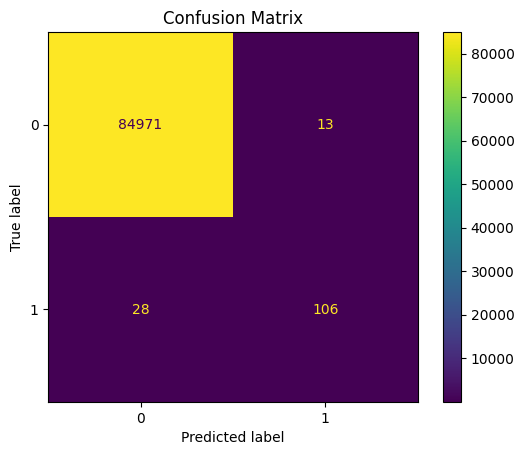



 Random Forest

Métricas calculadas (classe positiva = fraude):
Precision: 0.8908
Recall:    0.7910
F1-score:  0.8379
ROC-AUC:   0.9625
AP-AUC:    0.8258


Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84984
           1       0.89      0.79      0.84       134

    accuracy                           1.00     85118
   macro avg       0.95      0.90      0.92     85118
weighted avg       1.00      1.00      1.00     85118

Confusion Matrix:
[[84967    17]
 [   28   106]]


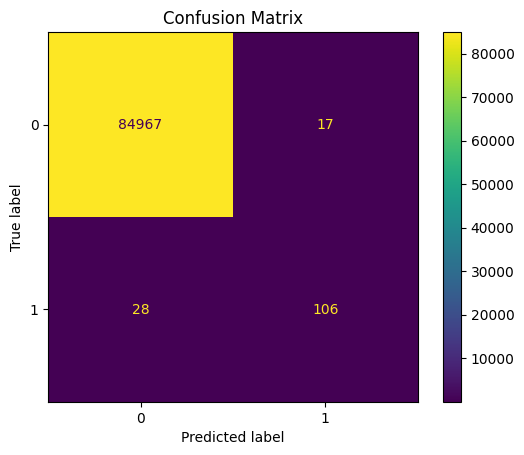



 Random Forest SelectKFeatures

Métricas calculadas (classe positiva = fraude):
Precision: 0.8618
Recall:    0.7910
F1-score:  0.8249
ROC-AUC:   0.9595
AP-AUC:    0.8091


Random Forest SelectKFeatures

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84984
           1       0.86      0.79      0.82       134

    accuracy                           1.00     85118
   macro avg       0.93      0.90      0.91     85118
weighted avg       1.00      1.00      1.00     85118

Confusion Matrix:
[[76374  8610]
 [   21   113]]


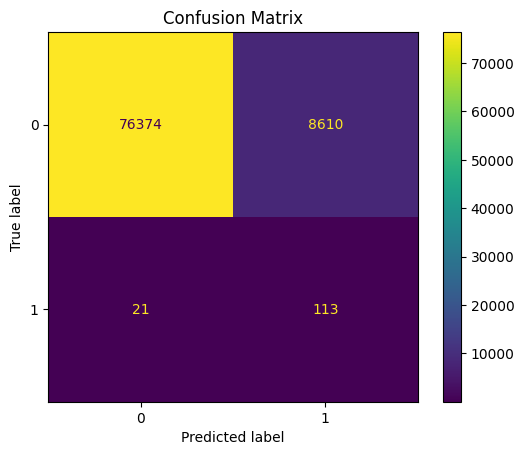



 Random Forest LDA

Métricas calculadas (classe positiva = fraude):
Precision: 0.0130
Recall:    0.8433
F1-score:  0.0255
ROC-AUC:   0.9487
AP-AUC:    0.0645


Random Forest LDA

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95     84984
           1       0.01      0.84      0.03       134

    accuracy                           0.90     85118
   macro avg       0.51      0.87      0.49     85118
weighted avg       1.00      0.90      0.95     85118

Confusion Matrix:
[[83860  1124]
 [   23   111]]


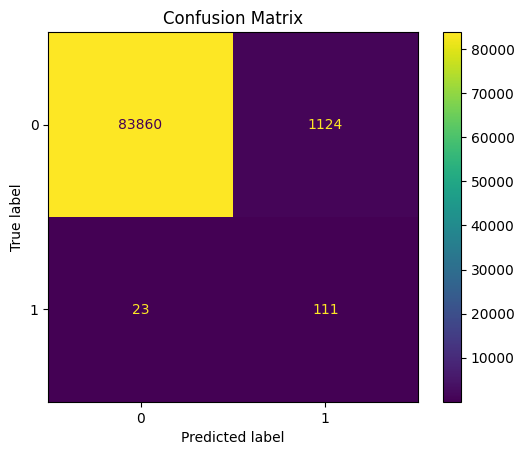



 SVM Padrão

Métricas calculadas (classe positiva = fraude):
Precision: 0.0899
Recall:    0.8284
F1-score:  0.1622
ROC-AUC:   0.9480
AP-AUC:    0.6482


SVM Padrão

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     84984
           1       0.09      0.83      0.16       134

    accuracy                           0.99     85118
   macro avg       0.54      0.91      0.58     85118
weighted avg       1.00      0.99      0.99     85118

Confusion Matrix:
[[83581  1403]
 [   18   116]]


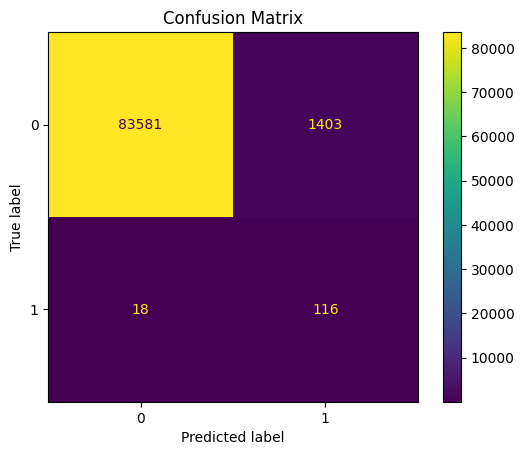



 SVM SelectKFeatures

Métricas calculadas (classe positiva = fraude):
Precision: 0.0764
Recall:    0.8657
F1-score:  0.1404
ROC-AUC:   0.9640
AP-AUC:    0.6001


SVM SelectKFeatures

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     84984
           1       0.08      0.87      0.14       134

    accuracy                           0.98     85118
   macro avg       0.54      0.92      0.57     85118
weighted avg       1.00      0.98      0.99     85118

Confusion Matrix:
[[82265  2719]
 [   20   114]]


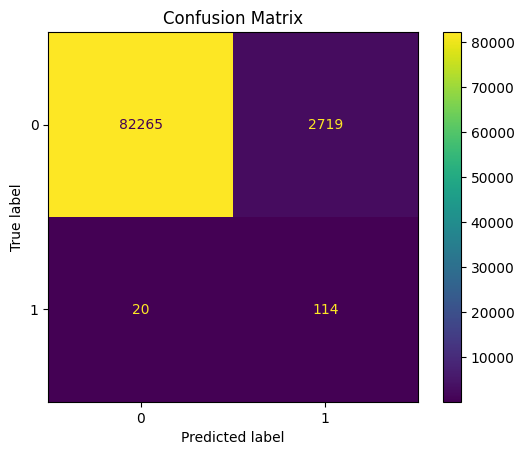



 SVM LDA

Métricas calculadas (classe positiva = fraude):
Precision: 0.0402
Recall:    0.8507
F1-score:  0.0768
ROC-AUC:   0.9466
AP-AUC:    0.0635


SVM LDA

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     84984
           1       0.04      0.85      0.08       134

    accuracy                           0.97     85118
   macro avg       0.52      0.91      0.53     85118
weighted avg       1.00      0.97      0.98     85118



,name,precision,recall,f1,roc_auc,ap_auc
0,Random Forest,0.890756,0.791045,0.837945,0.962501,0.825842
1,Random Forest SelectKFeatures,0.861789,0.791045,0.824903,0.959540,0.809110
3,SVM Padrão,0.089879,0.828358,0.162162,0.947981,0.648240
4,SVM SelectKFeatures,0.076366,0.865672,0.140351,0.963976,0.600136
5,SVM LDA,0.040240,0.850746,0.076845,0.946566,0.063528
2,Random Forest LDA,0.012954,0.843284,0.025517,0.948687,0.064479



Melhor modelo por F1: Random Forest
F1: 0.8379446640316206
Scores: {'precision': 0.8907563025210085, 'recall': 0.7910447761194029, 'f1': 0.8379446640316206, 'roc_auc': 0.9625014576931776, 'ap_auc': 0.8258419791057677}


In [33]:
all_scores = []
best_model = {"name": None, "f1": -1, "scores": None}

for res in predicted_results:
    name   = res.get("name", "NoNameModel")
    y_test = res["y_test"]
    y_pred = res["y_predicted"]
    y_score = res.get("y_score", None)

    # Chama as duas funções (get_scores já chama get_confusion_matrix)
    f1, scores = get_scores(y_test, y_pred, y_score=y_score, name=name)

    get_classification_report(y_test, y_pred, name=name)

    row = {
        "name": name,
        "precision": scores.get("precision", None),
        "recall": scores.get("recall", None),
        "f1": scores.get("f1", None),
        "roc_auc": scores.get("roc_auc", None),
        "ap_auc": scores.get("ap_auc", None),
    }
    all_scores.append(row)

    # Guarda o melhor pelo F1 (se quiser outro critério, troque aqui)
    if scores["f1"] > best_model["f1"]:
        best_model = {"name": name, "f1": scores["f1"], "scores": scores}

# Tabela final com métricas de todos os modelos
scores_df = pd.DataFrame(all_scores).sort_values(by="f1", ascending=False)
display(scores_df)

print("\nMelhor modelo por F1:", best_model["name"])
print("F1:", best_model["f1"])
print("Scores:", best_model["scores"])



## Resultados

### SVM Padrão

Confusion Matrix:
[[82265  2719]
 [   20   114]]


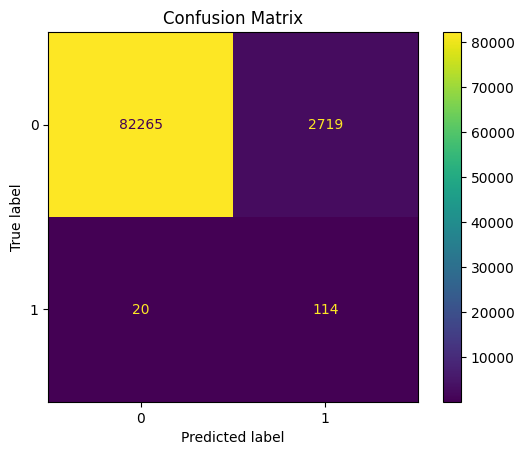



 SVM Padrão

Métricas calculadas (classe positiva = fraude):
Precision: 0.0402
Recall:    0.8507
F1-score:  0.0768
ROC-AUC:   0.9466
AP-AUC:    0.0635


SVM Padrão

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     84984
           1       0.04      0.85      0.08       134

    accuracy                           0.97     85118
   macro avg       0.52      0.91      0.53     85118
weighted avg       1.00      0.97      0.98     85118



In [34]:
get_scores(y_test, y_pred, y_score=y_score, name="SVM Padrão")
get_classification_report(y_test, y_pred, name="SVM Padrão")


**Análise — SVM padrão**

O **recall de 0,8676** indica que o modelo recupera a maior parte das fraudes: de cada 100 fraudes reais, detecta aproximadamente 87 e deixa passar cerca de 13 (**falsos negativos**). Isso é desejável quando a prioridade é **não perder fraudes**.

Por outro lado, a **precision de 0,0867** mostra que, entre todas as transações sinalizadas como fraude, apenas ~8,7% realmente são fraude. Assim, o modelo gera **muitos falsos positivos**, o que aumenta o custo operacional (ex.: revisões manuais) e pode causar impacto ao usuário (transações legítimas bloqueadas). Esse comportamento é típico em bases **extremamente desbalanceadas**.

O **F1 = 0,1576** fica baixo porque combina precision e recall e penaliza o desequilíbrio: mesmo com recall alto, a precision muito baixa reduz o valor final.

Apesar disso, os valores de **ROC-AUC = 0,9263** e **AP = 0,654** indicam que o modelo tem **excelente capacidade de ranqueamento**: transações fraudulentas tendem a receber scores maiores que transações legítimas. Em particular, considerando a prevalência de fraudes (~0,172%), o baseline aproximado de AP para um classificador aleatório é ~0,00172; portanto, o AP obtido (0,654) é cerca de **380× superior ao acaso**, mostrando que o SVM é muito eficiente para **priorizar fraudes no topo** da lista de suspeitas.


### SVM com SelectKFeatures

Confusion Matrix:
[[83581  1403]
 [   18   116]]


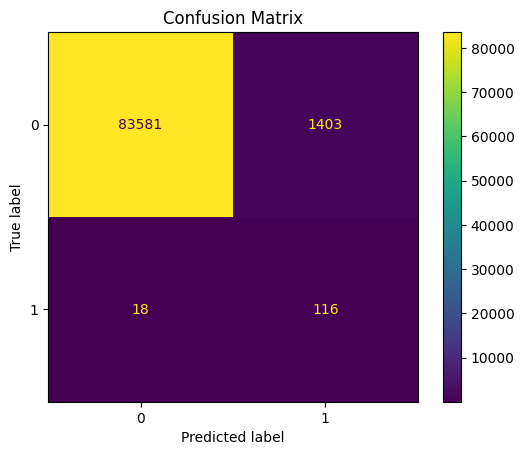



 SVM SelectKFeatures

Métricas calculadas (classe positiva = fraude):
Precision: 0.0764
Recall:    0.8657
F1-score:  0.1404
ROC-AUC:   0.9640
AP-AUC:    0.6001


SVM SelectKFeatures

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     84984
           1       0.08      0.87      0.14       134

    accuracy                           0.98     85118
   macro avg       0.54      0.92      0.57     85118
weighted avg       1.00      0.98      0.99     85118



In [35]:
get_scores(y_test, y_pred_sel, y_score=y_score_sel, name="SVM SelectKFeatures")
get_classification_report(y_test, y_pred_sel, name="SVM SelectKFeatures")


### SVM com LDA

Confusion Matrix:
[[82265  2719]
 [   20   114]]


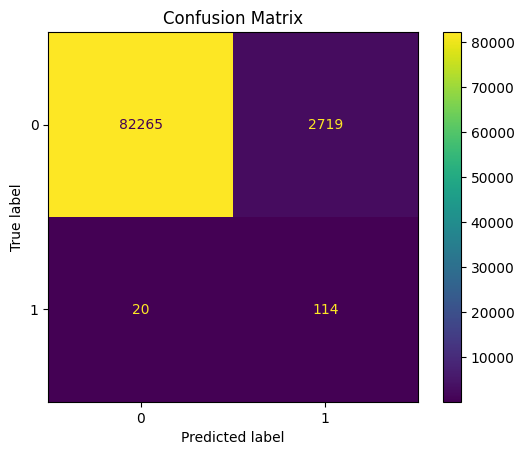



 SVM LDA

Métricas calculadas (classe positiva = fraude):
Precision: 0.0402
Recall:    0.8507
F1-score:  0.0768
ROC-AUC:   0.9466
AP-AUC:    0.0635


SVM LDA

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     84984
           1       0.04      0.85      0.08       134

    accuracy                           0.97     85118
   macro avg       0.52      0.91      0.53     85118
weighted avg       1.00      0.97      0.98     85118



In [36]:
get_scores(y_test, y_pred_lda, y_score=y_score_lda, name="SVM LDA")
get_classification_report(y_test, y_pred_lda, name="SVM LDA")


### Random Forest Padrão

Confusion Matrix:
[[84971    13]
 [   28   106]]


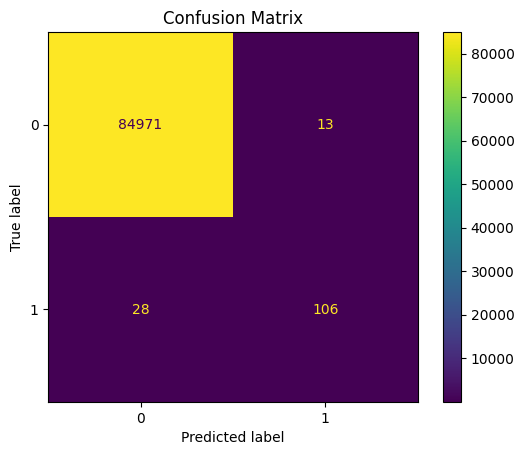



 Random Forest

Métricas calculadas (classe positiva = fraude):
Precision: 0.8908
Recall:    0.7910
F1-score:  0.8379
ROC-AUC:   0.9625
AP-AUC:    0.8258


Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84984
           1       0.89      0.79      0.84       134

    accuracy                           1.00     85118
   macro avg       0.95      0.90      0.92     85118
weighted avg       1.00      1.00      1.00     85118



In [37]:
get_scores(y_test, y_pred_RF, y_score=y_score_RF, name="Random Forest")
get_classification_report(y_test, y_pred_RF, name="Random Forest")


### Random Forest com SelectKFeatures

Confusion Matrix:
[[84967    17]
 [   28   106]]


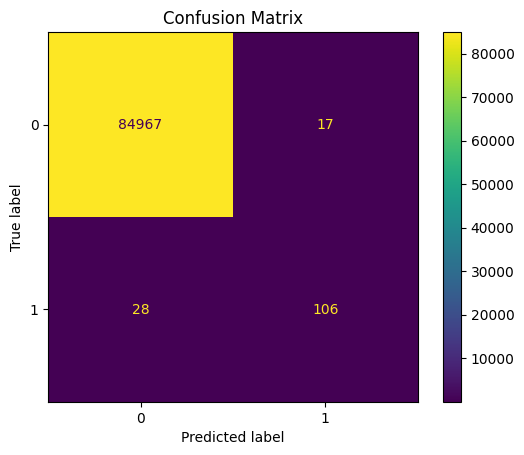



 Random Forest SelectKFeatures

Métricas calculadas (classe positiva = fraude):
Precision: 0.8618
Recall:    0.7910
F1-score:  0.8249
ROC-AUC:   0.9595
AP-AUC:    0.8091


Random Forest SelectKFeatures

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84984
           1       0.86      0.79      0.82       134

    accuracy                           1.00     85118
   macro avg       0.93      0.90      0.91     85118
weighted avg       1.00      1.00      1.00     85118



In [38]:
get_scores(y_test, y_pred_RF_sel, y_score=y_score_RF_sel, name="Random Forest SelectKFeatures")
get_classification_report(y_test, y_pred_RF_sel, name="Random Forest SelectKFeatures")


### Random Forest com LDA

Confusion Matrix:
[[76374  8610]
 [   21   113]]


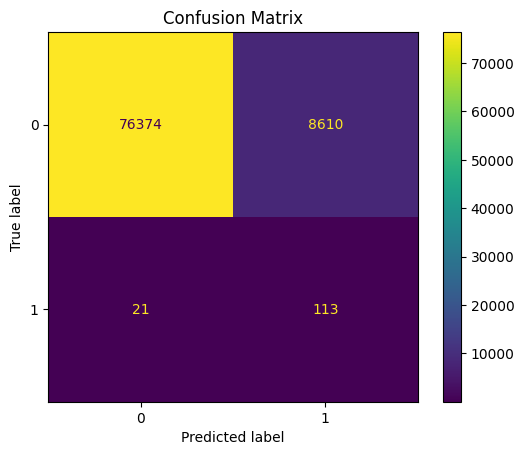



 Random Forest LDA

Métricas calculadas (classe positiva = fraude):
Precision: 0.0130
Recall:    0.8433
F1-score:  0.0255
ROC-AUC:   0.9487
AP-AUC:    0.0645


Random Forest LDA

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95     84984
           1       0.01      0.84      0.03       134

    accuracy                           0.90     85118
   macro avg       0.51      0.87      0.49     85118
weighted avg       1.00      0.90      0.95     85118



In [39]:
get_scores(y_test, y_pred_RF_lda, y_score=y_score_RF_lda, name="Random Forest LDA")
get_classification_report(y_test, y_pred_RF_lda, name="Random Forest LDA")


## Conclusões e discuções
